# 🇸🇪 Swedish Road Safety — Data Cleaning & Exploration

This notebook cleans and explores official Swedish road accident statistics 
from **Transport Analysis (Trafa)** covering the years 2020–2024.

**Goal:** Prepare clean datasets to build an interactive dashboard that tracks 
Sweden's progress toward **Vision Zero** — the goal of zero road fatalities.

**Data source:** https://www.trafa.se/en/road-traffic/road-traffic-injuries/

**Author:** Hafsa Limama | Data Analyst | Gothenburg, Sweden

## 1. Import Libraries

We start by importing the libraries we need:
- **pandas** — loading and cleaning data
- **numpy** — numerical operations
- **matplotlib & seaborn** — data visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load & Explore the Data

Each yearly Excel file from Trafa contains 32 sheets. We first explore 
the 2024 file to understand the structure before loading all 5 years.

In [8]:
df = pd.read_excel("../Data/Raw/vagtrafikskador-2024.xlsx", sheet_name=None)
print("Number of sheets:", len(df))
print("Sheet names:", list(df.keys()))

Number of sheets: 32
Sheet names: ['Titel _ Title', 'Innehåll _ Content', 'Kort om statistiken _ In brief', 'Teckenförklaring_Legends', '0.0', '1.1', '1.2', '1.3', '1.4', '1.5', '2.1', '2.2', '2.3', '2.4', '3.1', '3.2', '3.3', '4.1', '4.2', '5.1', '5.2', '5.3', '5.4', '6.1', '6.2', '6.3', 'Befolkning SE', '6.4', '6.5', '6.6', '7.1', '7.2']


## 3. Long-Term Trend (Sheet 6.1)

Sheet 6.1 contains the full historical series from **1960 to 2024** — 
total accidents, fatalities, and injured persons per year.

This is our most important sheet for tracking Vision Zero progress over time.

In [9]:
df_61 = pd.read_excel("../Data/Raw/vagtrafikskador-2024.xlsx", sheet_name="6.1", header=None)
df_61

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,Tabell 6.1. Polisrapporterade vägtrafikolyckor...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"därvid dödade, svårt och lindrigt skadade pers...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Table 6.1. Road traffic accidents with fatal, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"killed, severely and slightly injured, by seve...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,2020,189,NaN,1426,NaN,10628,NaN,12243,NaN,204,NaN,1645,NaN,13709,NaN,15558
73,2021,194,NaN,1483,NaN,10948,NaN,12625,NaN,210,NaN,1718,NaN,14219,NaN,16147
74,2022,208,NaN,1671,NaN,10729,NaN,12608,NaN,227,NaN,1891,NaN,13370,NaN,15488
75,2023,217,NaN,1549,NaN,9967,NaN,11733,NaN,229,NaN,1789,NaN,12923,NaN,14941


In [10]:
# Skip the first 11 rows (titles and headers) and grab only useful columns
df_trend = pd.read_excel("../Data/Raw/vagtrafikskador-2024.xlsx", sheet_name="6.1", header=None, skiprows=11)

# Keep only the columns we need and rename them
df_trend = df_trend[[0, 1, 3, 5, 7, 9, 11, 13, 15]].copy()
df_trend.columns = ["year", "fatal_accidents", "severe_accidents", "slight_accidents", 
                    "total_accidents", "killed", "severely_injured", "slightly_injured", "total_injured"]

# Keep only rows where year is a valid number
df_trend = df_trend[pd.to_numeric(df_trend["year"], errors="coerce").notna()]
df_trend["year"] = df_trend["year"].astype(int)

df_trend.head(10)

,year,fatal_accidents,severe_accidents,slight_accidents,total_accidents,killed,severely_injured,slightly_injured,total_injured
1,1960,970.0,2514.0,13739.0,17223.0,1036.0,2983.0,18553.0,22572.0
2,1961,1020.0,2548.0,14490.0,18058.0,1083.0,3031.0,19867.0,23981.0
3,1962,1022.0,2454.0,14042.0,17518.0,1123.0,2942.0,19496.0,23561.0
4,1963,1126.0,2555.0,14549.0,18230.0,1217.0,3068.0,20332.0,24617.0
5,1964,1202.0,2739.0,15397.0,19338.0,1308.0,3370.0,21565.0,26243.0
6,1965,1204.0,2517.0,14423.0,18144.0,1313.0,3158.0,20460.0,24931.0
7,1966,1168.0,3645.0,11397.0,16210.0,1313.0,4700.0,16730.0,22743.0
8,1967,968.0,4011.0,10429.0,15408.0,1077.0,5304.0,15697.0,22078.0
9,1968,1133.0,4607.0,11077.0,16817.0,1262.0,6117.0,16917.0,24296.0
10,1969,1158.0,5085.0,11094.0,17337.0,1275.0,5989.0,16670.0,23934.0


In [11]:
print("Shape:", df_trend.shape)
print("\nYears range:", df_trend["year"].min(), "to", df_trend["year"].max())
print("\nMissing values:\n", df_trend.isnull().sum())
print("\nLast 5 rows:")
df_trend.tail()

Shape: (65, 9)

Years range: 1960 to 2024

Missing values:
 year                0
fatal_accidents     0
severe_accidents    0
slight_accidents    0
total_accidents     0
killed              0
severely_injured    0
slightly_injured    0
total_injured       0
dtype: int64

Last 5 rows:


,year,fatal_accidents,severe_accidents,slight_accidents,total_accidents,killed,severely_injured,slightly_injured,total_injured
61,2020,189.0,1426.0,10628.0,12243.0,204.0,1645.0,13709.0,15558.0
62,2021,194.0,1483.0,10948.0,12625.0,210.0,1718.0,14219.0,16147.0
63,2022,208.0,1671.0,10729.0,12608.0,227.0,1891.0,13370.0,15488.0
64,2023,217.0,1549.0,9967.0,11733.0,229.0,1789.0,12923.0,14941.0
65,2024,193.0,1405.0,9652.0,11250.0,213.0,1597.0,12268.0,14078.0


### 📊 Visualization — Fatality Trend Since 2000

We filter to year 2000 onwards to focus on the Vision Zero era.
The clear downward trend shows Sweden's road safety policies are working.

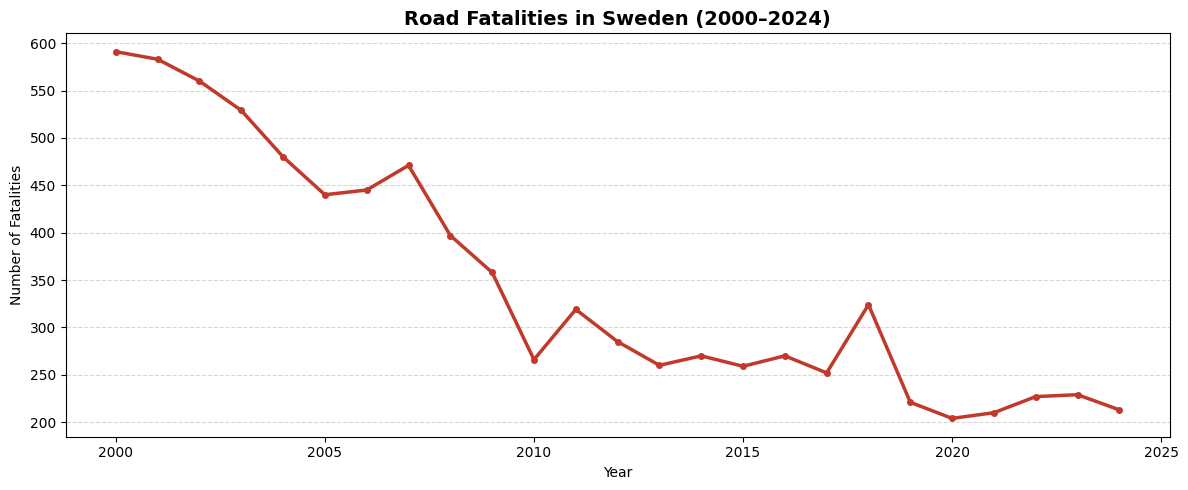


2000: 591 fatalities
2024: 213 fatalities


In [12]:
# Filter to recent years for a cleaner view
df_recent = df_trend[df_trend["year"] >= 2000]

plt.figure(figsize=(12, 5))
plt.plot(df_recent["year"], df_recent["killed"], color="#C0392B", linewidth=2.5, marker="o", markersize=4)
plt.title("Road Fatalities in Sweden (2000–2024)", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Number of Fatalities")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"\n2000: {int(df_trend[df_trend['year']==2000]['killed'].values[0])} fatalities")
print(f"2024: {int(df_trend[df_trend['year']==2024]['killed'].values[0])} fatalities")

In [13]:
import os

# Create a folder to save our clean data
os.makedirs("../Data/Processed", exist_ok=True)

# Save the trend data
df_trend.to_csv("../Data/Processed/trend.csv", index=False)

print("✅ Saved! Let's check it:")
print(pd.read_csv("../Data/Processed/trend.csv").tail())

✅ Saved! Let's check it:
    year  fatal_accidents  severe_accidents  slight_accidents  \
60  2020            189.0            1426.0           10628.0   
61  2021            194.0            1483.0           10948.0   
62  2022            208.0            1671.0           10729.0   
63  2023            217.0            1549.0            9967.0   
64  2024            193.0            1405.0            9652.0   

    total_accidents  killed  severely_injured  slightly_injured  total_injured  
60          12243.0   204.0            1645.0           13709.0        15558.0  
61          12625.0   210.0            1718.0           14219.0        16147.0  
62          12608.0   227.0            1891.0           13370.0        15488.0  
63          11733.0   229.0            1789.0           12923.0        14941.0  
64          11250.0   213.0            1597.0           12268.0        14078.0  


In [14]:
files = {
    2020: "../Data/Raw/vagtrafikskador-2020---korr_-2021-10-21.xlsx",
    2021: "../Data/Raw/vagtrafikskador-2021---kompl_-2022-05-23.xlsx",
    2022: "../Data/Raw/vagtrafikskador-2022---2023-05-09.xlsx",
    2023: "../Data/Raw/vagtrafikskador-2023---kompletterad-2024-06-24.xlsx",
    2024: "../Data/Raw/vagtrafikskador-2024.xlsx",
}

# Let's first look at sheet 1.2 raw to understand the structure
df_12 = pd.read_excel(files[2024], sheet_name="1.2", header=None)
df_12.iloc[13:55, :6]

,0,1,2,3,4,5
13,NaN,NaN,NaN,NaN,NaN,NaN
14,Samtliga,1598,193,1405,1810,213
15,NaN,NaN,NaN,NaN,NaN,NaN
16,Januari,91,8,83,102,9
17,Februari,79,11,68,100,13
18,Mars,86,5,81,98,5
19,NaN,NaN,NaN,NaN,NaN,NaN
20,April,111,10,101,123,12
21,Maj,183,26,157,216,30
22,Juni,197,19,178,221,22


In [15]:
import os

os.makedirs("../Data/Processed", exist_ok=True)
df_trend.to_csv("../Data/Processed/trend.csv", index=False)

print("✅ Saved!")
print(pd.read_csv("../Data/Processed/trend.csv").tail())

✅ Saved!
    year  fatal_accidents  severe_accidents  slight_accidents  \
60  2020            189.0            1426.0           10628.0   
61  2021            194.0            1483.0           10948.0   
62  2022            208.0            1671.0           10729.0   
63  2023            217.0            1549.0            9967.0   
64  2024            193.0            1405.0            9652.0   

    total_accidents  killed  severely_injured  slightly_injured  total_injured  
60          12243.0   204.0            1645.0           13709.0        15558.0  
61          12625.0   210.0            1718.0           14219.0        16147.0  
62          12608.0   227.0            1891.0           13370.0        15488.0  
63          11733.0   229.0            1789.0           12923.0        14941.0  
64          11250.0   213.0            1597.0           12268.0        14078.0  


In [16]:
FILES = {
    2020: "../Data/Raw/vagtrafikskador-2020---korr_-2021-10-21.xlsx",
    2021: "../Data/Raw/vagtrafikskador-2021---kompl_-2022-05-23.xlsx",
    2022: "../Data/Raw/vagtrafikskador-2022---2023-05-09.xlsx",
    2023: "../Data/Raw/vagtrafikskador-2023---kompletterad-2024-06-24.xlsx",
    2024: "../Data/Raw/vagtrafikskador-2024.xlsx",
}

# Load sheet 1.2 for 2024 first to understand the structure
df_12 = pd.read_excel(FILES[2024], sheet_name="1.2", header=None)
df_12.iloc[13:55, :6]

,0,1,2,3,4,5
13,NaN,NaN,NaN,NaN,NaN,NaN
14,Samtliga,1598,193,1405,1810,213
15,NaN,NaN,NaN,NaN,NaN,NaN
16,Januari,91,8,83,102,9
17,Februari,79,11,68,100,13
18,Mars,86,5,81,98,5
19,NaN,NaN,NaN,NaN,NaN,NaN
20,April,111,10,101,123,12
21,Maj,183,26,157,216,30
22,Juni,197,19,178,221,22


## 4. Accidents by Month (Sheet 1.2)

Sheet 1.2 contains accidents broken down by **month, weekday and hour**.
We extract each separately across all 5 years (2020–2024).

**Question we are answering:** When during the year do most accidents happen?

In [20]:
MONTHS_SV = {
    "Januari": "January", "Februari": "February", "Mars": "March",
    "April": "April", "Maj": "May", "Juni": "June",
    "Juli": "July", "Augusti": "August", "September": "September",
    "Oktober": "October", "November": "November", "December": "December",
}

months_all = []

for year, filepath in FILES.items():
    df = pd.read_excel(filepath, sheet_name="1.2", header=None)
    for _, row in df.iterrows():
        if str(row[0]).strip() in MONTHS_SV:
            months_all.append({
                "year":      year,
                "month":     MONTHS_SV[str(row[0]).strip()],
                "month_n":   list(MONTHS_SV.keys()).index(str(row[0]).strip()) + 1,
                "accidents": pd.to_numeric(row[1], errors="coerce"),
                "killed":    pd.to_numeric(row[5], errors="coerce"),
            })

df_months = pd.DataFrame(months_all)
print("Shape:", df_months.shape)
df_months.head(12)

Shape: (60, 5)


,year,month,month_n,accidents,killed
0,2020,January,1,117,20
1,2020,February,2,111,14
2,2020,March,3,75,9
3,2020,April,4,110,17
4,2020,May,5,135,18
5,2020,June,6,209,17
6,2020,July,7,168,19
7,2020,August,8,163,18
8,2020,September,9,158,21
9,2020,October,10,128,12


In [19]:
FILES = {
    2020: "../Data/Raw/vagtrafikskador-2020---korr.-2021-10-21.xlsx",
    2021: "../Data/Raw/vagtrafikskador-2021---kompl.-2022-05-23.xlsx",
    2022: "../Data/Raw/vagtrafikskador-2022---2023-05-09.xlsx",
    2023: "../Data/Raw/vagtrafikskador-2023---kompletterad-2024-06-24.xlsx",
    2024: "../Data/Raw/vagtrafikskador-2024.xlsx",
}

print("✅ Files defined!")

✅ Files defined!


### 📊 Visualization — Monthly Pattern

We expect summer months to show higher accident rates due to 
more traffic, tourism, and longer driving distances.

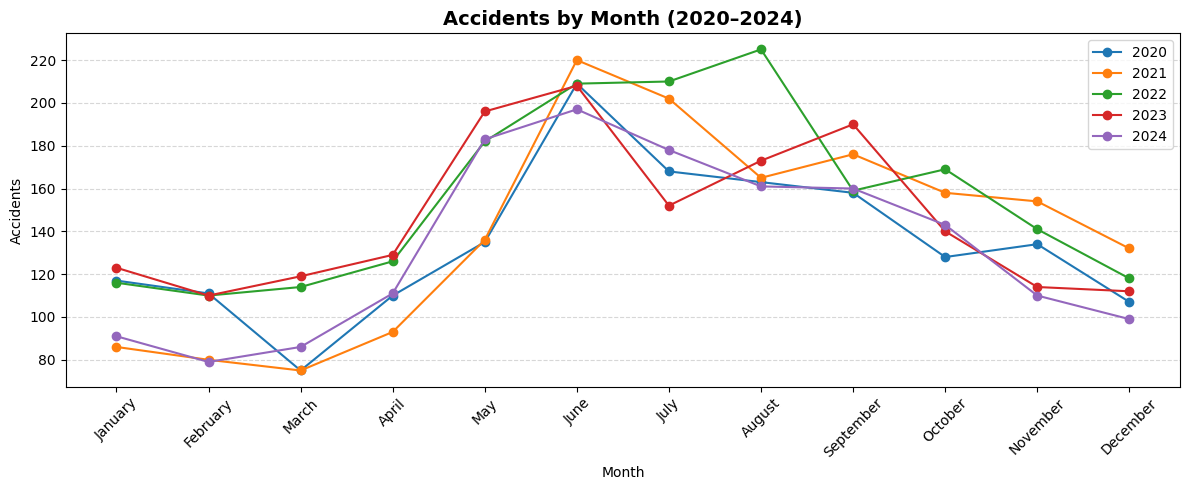

In [21]:
plt.figure(figsize=(12, 5))

for year in df_months["year"].unique():
    df_y = df_months[df_months["year"] == year].sort_values("month_n")
    plt.plot(df_y["month_n"], df_y["accidents"], marker="o", label=str(year))

plt.xticks(range(1, 13), list(MONTHS_SV.values()), rotation=45)
plt.title("Accidents by Month (2020–2024)", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Accidents")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [22]:
df_months.to_csv("../Data/Processed/by_month.csv", index=False)
print("✅ Monthly data saved!")

✅ Monthly data saved!


### Accidents by Weekday

**Question we are answering:** Which days of the week are most dangerous?

Friday and Saturday are highlighted in red as we expect them 
to show higher accident rates.

In [23]:
DAYS_SV = {
    "Måndag": "Monday", "Tisdag": "Tuesday", "Onsdag": "Wednesday",
    "Torsdag": "Thursday", "Fredag": "Friday", "Lördag": "Saturday",
    "Söndag": "Sunday",
}

days_all = []

for year, filepath in FILES.items():
    df = pd.read_excel(filepath, sheet_name="1.2", header=None)
    for _, row in df.iterrows():
        if str(row[0]).strip() in DAYS_SV:
            days_all.append({
                "year":      year,
                "day":       DAYS_SV[str(row[0]).strip()],
                "day_n":     list(DAYS_SV.keys()).index(str(row[0]).strip()) + 1,
                "accidents": pd.to_numeric(row[1], errors="coerce"),
                "killed":    pd.to_numeric(row[5], errors="coerce"),
            })

df_days = pd.DataFrame(days_all)
print("Shape:", df_days.shape)
df_days.head(7)

Shape: (35, 5)


,year,day,day_n,accidents,killed
0,2020,Monday,1,226,29
1,2020,Tuesday,2,208,26
2,2020,Wednesday,3,243,34
3,2020,Thursday,4,242,29
4,2020,Friday,5,242,26
5,2020,Saturday,6,247,31
6,2020,Sunday,7,207,29


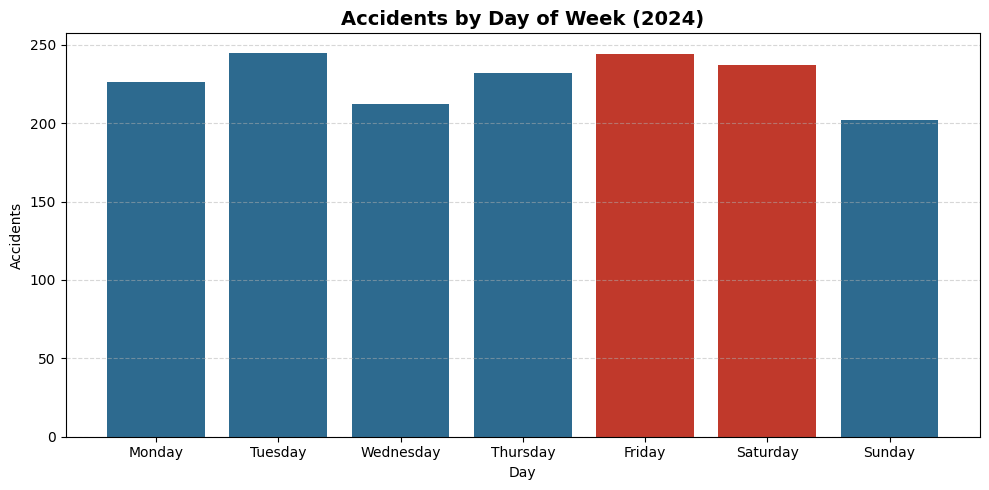

In [24]:
df_2024_days = df_days[df_days["year"] == 2024].sort_values("day_n")

plt.figure(figsize=(10, 5))
colors = ["#C0392B" if d in ["Friday", "Saturday"] else "#2D6A8F" for d in df_2024_days["day"]]
plt.bar(df_2024_days["day"], df_2024_days["accidents"], color=colors)
plt.title("Accidents by Day of Week (2024)", fontsize=14, fontweight="bold")
plt.xlabel("Day")
plt.ylabel("Accidents")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [25]:
df_days.to_csv("../Data/Processed/by_day.csv", index=False)
print("✅ Weekday data saved!")

✅ Weekday data saved!


### Accidents by Hour of Day

**Question we are answering:** What time of day are roads most dangerous?

We expect the afternoon rush hour (14:00–18:00) to show the highest 
accident rates due to high traffic volume and driver fatigue after work.

In [26]:
hours_all = []

for year, filepath in FILES.items():
    df = pd.read_excel(filepath, sheet_name="1.2", header=None)
    for _, row in df.iterrows():
        val = str(row[0]).strip()
        if ":" in val and "-" in val:
            hours_all.append({
                "year":      year,
                "hour_slot": val,
                "accidents": pd.to_numeric(row[1], errors="coerce"),
                "killed":    pd.to_numeric(row[5], errors="coerce"),
            })

df_hours = pd.DataFrame(hours_all)
print("Shape:", df_hours.shape)
df_hours.head(10)

Shape: (60, 4)


,year,hour_slot,accidents,killed
0,2020,00:00-01:59,79,10
1,2020,02:00-03:59,47,14
2,2020,04:00-05:59,38,6
3,2020,06:00-07:59,120,12
4,2020,08:00-09:59,113,12
5,2020,10:00-11:59,122,16
6,2020,12:00-13:59,171,25
7,2020,14:00-15:59,244,29
8,2020,16:00-17:59,255,25
9,2020,18:00-19:59,182,12


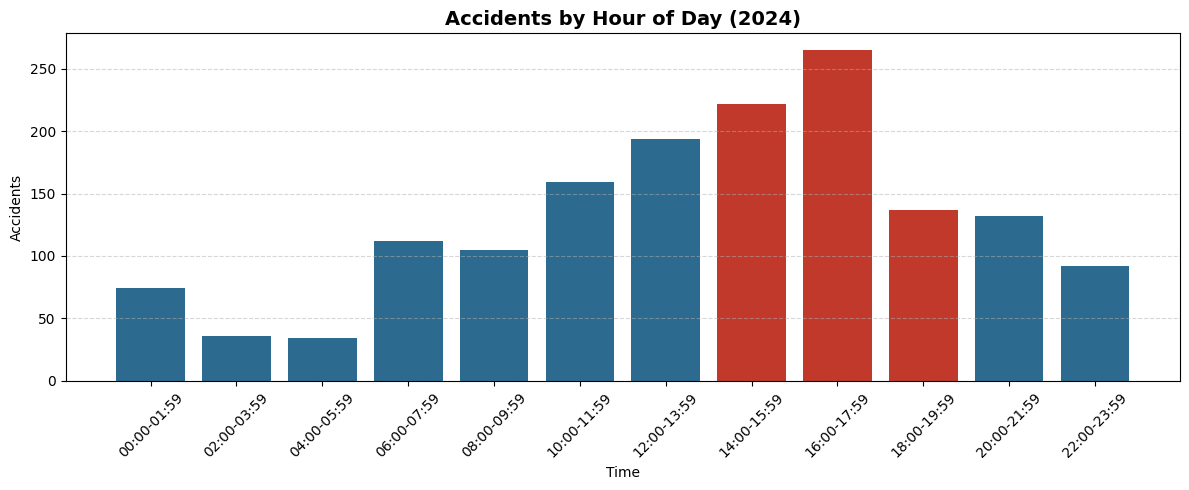

In [27]:
df_2024_hours = df_hours[df_hours["year"] == 2024].copy()
df_2024_hours["hour_start"] = df_2024_hours["hour_slot"].str.extract(r"(\d+):").astype(int)
df_2024_hours = df_2024_hours.sort_values("hour_start")

plt.figure(figsize=(12, 5))
colors = ["#C0392B" if 14 <= h <= 18 else "#2D6A8F" for h in df_2024_hours["hour_start"]]
plt.bar(df_2024_hours["hour_slot"], df_2024_hours["accidents"], color=colors)
plt.title("Accidents by Hour of Day (2024)", fontsize=14, fontweight="bold")
plt.xlabel("Time")
plt.ylabel("Accidents")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [28]:
df_hours.to_csv("../Data/Processed/by_hour.csv", index=False)
print("✅ Hourly data saved!")

✅ Hourly data saved!


## 5. Accidents by County (Sheet 1.1)

Sheet 1.1 breaks down accidents by Swedish county (län).
Sweden has 21 counties  we extract data for all of them across 2020–2024.

**Question we are answering:** Where in Sweden do most accidents happen?

Note: **Västra Götalands län** (Gothenburg) is highlighted as it is 
one of Sweden's most populated regions.

In [29]:
COUNTIES = [
    "Stockholms län", "Uppsala län", "Södermanlands län", "Östergötlands län",
    "Jönköpings län", "Kronobergs län", "Kalmar län", "Gotlands län",
    "Blekinge län", "Skåne län", "Hallands län", "Västra Götalands län",
    "Värmlands län", "Örebro län", "Västmanlands län", "Dalarnas län",
    "Gävleborgs län", "Västernorrlands län", "Jämtlands län",
    "Västerbottens län", "Norrbottens län",
]

counties_all = []

for year, filepath in FILES.items():
    df = pd.read_excel(filepath, sheet_name="1.1", header=None)
    for _, row in df.iterrows():
        if str(row[0]).strip() in COUNTIES:
            counties_all.append({
                "year":             year,
                "county":           str(row[0]).strip(),
                "total_accidents":  pd.to_numeric(row[1], errors="coerce"),
                "fatal_accidents":  pd.to_numeric(row[2], errors="coerce"),
                "total_injured":    pd.to_numeric(row[4], errors="coerce"),
                "killed":           pd.to_numeric(row[5], errors="coerce"),
            })

df_counties = pd.DataFrame(counties_all)
print("Shape:", df_counties.shape)
df_counties.head(10)

Shape: (105, 6)


,year,county,total_accidents,fatal_accidents,total_injured,killed
0,2020,Stockholms län,319,13,353,13
1,2020,Uppsala län,53,7,57,8
2,2020,Södermanlands län,47,5,52,5
3,2020,Östergötlands län,64,13,74,13
4,2020,Jönköpings län,71,5,85,5
5,2020,Kronobergs län,25,6,30,6
6,2020,Kalmar län,46,6,54,7
7,2020,Gotlands län,20,2,21,2
8,2020,Blekinge län,30,2,31,2
9,2020,Skåne län,223,36,243,39


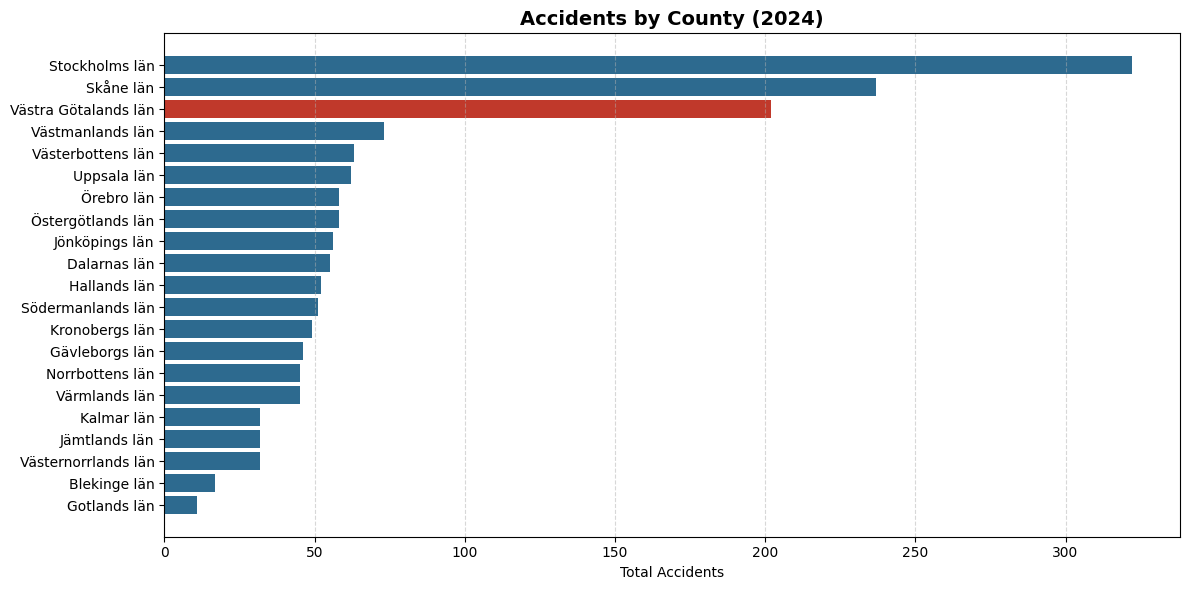

In [30]:
df_2024_counties = df_counties[df_counties["year"] == 2024].sort_values("total_accidents", ascending=False)

plt.figure(figsize=(12, 6))
colors = ["#C0392B" if "Västra Götaland" in c else "#2D6A8F" for c in df_2024_counties["county"]]
plt.barh(df_2024_counties["county"], df_2024_counties["total_accidents"], color=colors)
plt.title("Accidents by County (2024)", fontsize=14, fontweight="bold")
plt.xlabel("Total Accidents")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [31]:
df_counties.to_csv("../Data/Processed/by_county.csv", index=False)
print("✅ County data saved!")

✅ County data saved!


## 6. Fatalities by Road User Type (Sheet 3.1)

Sheet 3.1 shows who gets killed  car drivers, cyclists, pedestrians etc.
We extract the national totals ("Hela riket") for each year.

**Question we are answering:** Who is most at risk on Swedish roads?

This is critical for Vision Zero  protecting vulnerable road users 
like cyclists and pedestrians is a key policy priority.

In [32]:
users_all = []

for year, filepath in FILES.items():
    df = pd.read_excel(filepath, sheet_name="3.1", header=None)
    for _, row in df.iterrows():
        if str(row[0]).strip() == "Hela riket":
            row = row.reset_index(drop=True)
            users_all.append({
                "year":          year,
                "total":         pd.to_numeric(row[1],  errors="coerce"),
                "car_driver":    pd.to_numeric(row[2],  errors="coerce"),
                "car_passenger": pd.to_numeric(row[3],  errors="coerce"),
                "motorcycle":    pd.to_numeric(row[6],  errors="coerce"),
                "moped":         pd.to_numeric(row[8],  errors="coerce"),
                "cyclist":       pd.to_numeric(row[9],  errors="coerce"),
                "pedestrian":    pd.to_numeric(row[10], errors="coerce"),
                "other":         pd.to_numeric(row[11], errors="coerce"),
            })

df_users = pd.DataFrame(users_all)
print("Shape:", df_users.shape)
df_users

Shape: (5, 9)


,year,total,car_driver,car_passenger,motorcycle,moped,cyclist,pedestrian,other
0,2020,204,78,28,28,4,18,25,7
1,2021,210,74,29,27,3,24,26,8
2,2022,227,79,21,29,11,26,27,17
3,2023,229,77,33,29,3,30,24,13
4,2024,213,70,33,31,2,27,30,6


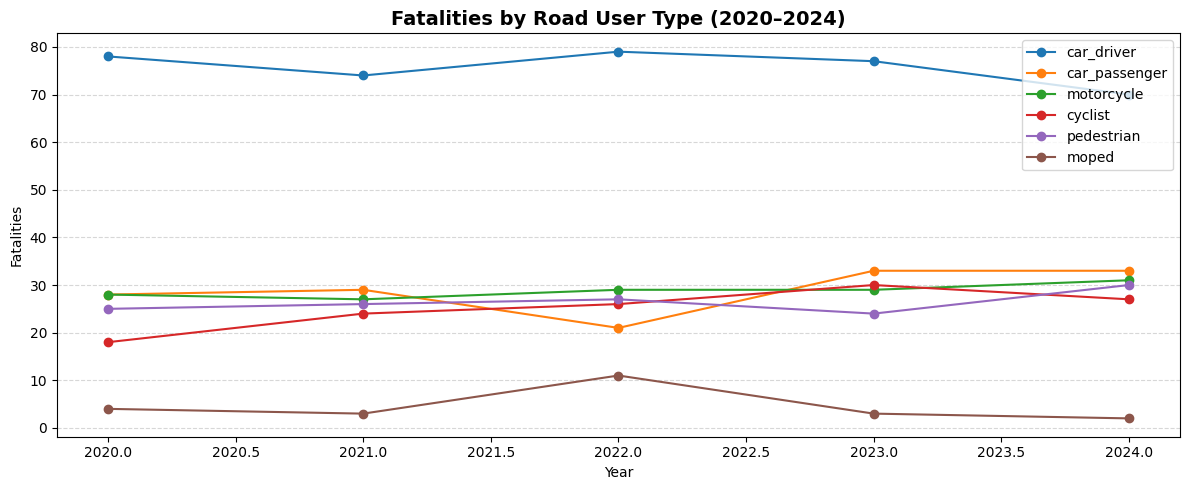

In [33]:
# Melt the data for easier plotting
df_users_long = df_users.melt(
    id_vars="year",
    value_vars=["car_driver", "car_passenger", "motorcycle", "cyclist", "pedestrian", "moped"],
    var_name="user_type",
    value_name="killed"
)

plt.figure(figsize=(12, 5))
for user in df_users_long["user_type"].unique():
    df_u = df_users_long[df_users_long["user_type"] == user]
    plt.plot(df_u["year"], df_u["killed"], marker="o", label=user)

plt.title("Fatalities by Road User Type (2020–2024)", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Fatalities")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [34]:
df_users.to_csv("../Data/Processed/by_road_users.csv", index=False)
print("✅ Road users data saved!")

✅ Road users data saved!


In [35]:
print("Files in Data/Processed:")
for f in os.listdir("../Data/Processed"):
    print(" ✅", f)

Files in Data/Processed:
 ✅ by_county.csv
 ✅ by_day.csv
 ✅ by_hour.csv
 ✅ by_month.csv
 ✅ by_road_users.csv
 ✅ trend.csv


## 7. Summary

### ✅ Data Saved
All 6 clean datasets saved to `Data/Processed/`:

| File | Contents |
|------|----------|
| trend.csv | Fatalities 1960–2024 |
| by_month.csv | Accidents by month 2020–2024 |
| by_day.csv | Accidents by weekday 2020–2024 |
| by_hour.csv | Accidents by hour 2020–2024 |
| by_county.csv | Accidents by county 2020–2024 |
| by_road_users.csv | Fatalities by road user 2020–2024 |

### 🔍 Key Findings
- 📉 Road fatalities dropped **80%+ since 1970** — Vision Zero is working
- ☀️ **Summer months** (May–August) have significantly more accidents
- 📆 **Friday and Saturday** are the most dangerous days
- 🕓 **Afternoon rush hour (14:00–18:00)** has the highest accident rate
- 🚗 **Car drivers** account for the most fatalities
- 🚴 **Cyclists and pedestrians** are the most vulnerable road users

### ➡️ Next Step
Build an interactive Streamlit dashboard using these clean datasets.